In [20]:
# Ejecuta esta celda para instalar todas las librerías necesarias
!pip install tensorflow pillow matplotlib scipy

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense,Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_TRAINABLE_LAYERS = 0 # Change this to >0 when you want to fine-tune
BASE_DIR = Path.cwd()
# === Directories ===
TRAIN_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "test"


# === Data Generators ===
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
rotation_range=20,
width_shift_range=0.2,
height_shift_range=0.2,
zoom_range=0.2,
horizontal_flip=True)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
TRAIN_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
VALIDATION_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
TEST_DATA_DIR,
target_size=(IMG_WIDTH, IMG_HEIGHT),
batch_size=BATCH_SIZE,
class_mode="sparse",
shuffle=False)

# === Load and Configure VGG16 ===
base_model = VGG16(weights='imagenet', include_top=False #No incluye la Red Neuronal Densa
, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Freeze all layers first
for layer in base_model.layers:
  layer.trainable = False

# Unfreeze last N layers
if NUM_TRAINABLE_LAYERS > 0:
  for layer in base_model.layers[-NUM_TRAINABLE_LAYERS:]:
    layer.trainable = True

base_model.summary()


Found 4000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [23]:

# === Build the Model ===
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation="softmax")
])

# === Compile ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#EarlyStopping
es = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True
)
# === Train ===
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[es]
)



Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 392s 3s/step - accuracy: 0.5673 - loss: 2.0040 - val_accuracy: 0.9120 - val_loss: 0.2630
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 393s 3s/step - accuracy: 0.8428 - loss: 0.4967 - val_accuracy: 0.9620 - val_loss: 0.0856
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 357s 3s/step - accuracy: 0.9118 - loss: 0.2515 - val_accuracy: 0.9780 - val_loss: 0.0489
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.9375 - loss: 0.1874 - val_accuracy: 0.9960 - val_loss: 0.0264
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.9488 - loss: 0.1454 - val_accuracy: 0.9960 - val_loss: 0.0182
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 354s 3s/step - accuracy: 0.9650 - loss: 0.1078 - val_accuracy: 0.9980 - val_loss: 0.0142
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9690 - loss: 0.0975 - val_accuracy: 0.9980 - val_loss: 0.0109
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.9645 - loss: 0.0930 - val_accu

In [ ]:
model.save("modelo_peces_vgg16.keras")
print("¡Modelo guardado con éxito en el disco!")

¡Modelo guardado con éxito en el disco!


¡Modelo cargado desde el disco con éxito!
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9940 - loss: 0.0125
Test Accuracy (del modelo cargado): 0.9940


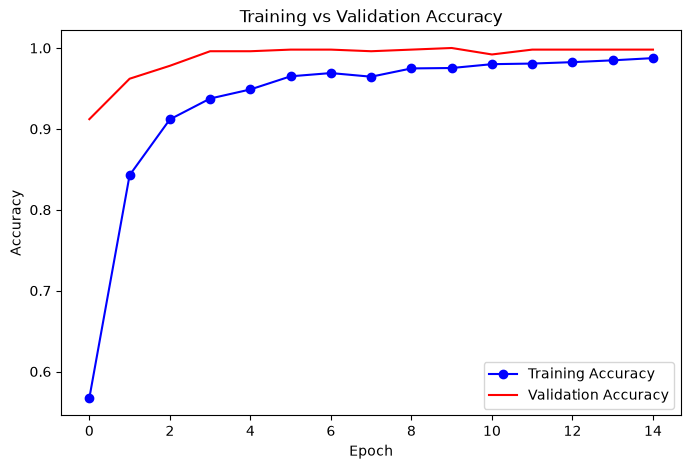

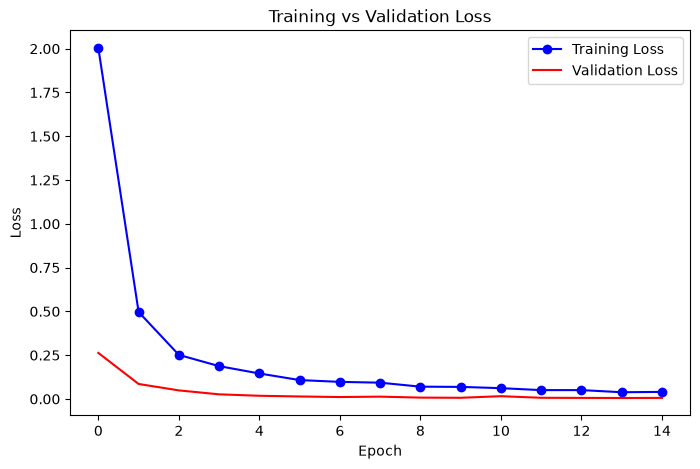

In [ ]:
ruta_guardado = r"C:\IA-FAC\modelo_peces_vgg16.keras"

# 2. Cargamos exactamente el archivo que acabamos de guardar
modelo_cargado = load_model(ruta_guardado)
print("¡Modelo cargado desde el disco con éxito!")
# === Evaluar sin pisar el historial ===
# Cambiamos los nombres a 'test_loss' y 'test_acc' para proteger las listas del historial
test_loss, test_acc = modelo_cargado.evaluate(test_generator)
print(f"Test Accuracy (del modelo cargado): {test_acc:.4f}")

# === Extraer historiales originales ===
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(accuracy))

# === Gráfica 1: Accuracy ===
plt.figure(figsize=(8,5))
plt.plot(epochs, accuracy, "bo-", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "r-", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# === Gráfica 2: Loss ===
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r-", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()